In [1]:
%load_ext autoreload
%autoreload 2

In [491]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import torch
import torch.nn as nn
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid', font_scale=2, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from rna_vel_pred import datasets, utils, plots, main as main_module

In [3]:
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [690]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        # 'datasets=[{_target_:conf.datasets.H5adUMap,dataset:PANCREAS,umap_dimension:2}]',
        'datasets=[{_target_:conf.datasets.H5adUMap,dataset:DENTATE_GYRUS,neighbor_count:113,time_step_count_sparsify:24,umap_dimension:2},{_target_:conf.datasets.H5adUMap,dataset:BONEMARROW,neighbor_count:113,time_step_count_sparsify:48,umap_dimension:2}]',#,{_target_:conf.datasets.H5adUMap,dataset:FOREBRAIN,neighbor_count:113,time_step_count_sparsify:173,umap_dimension:2,reverse_velocities:true}]',
        # 'datasets=[{_target_:conf.datasets.SimpleMotif}]',
        'model=First',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/home/ttransue/GitHub/velocityPrediction',
     out_dir='/home/ttransue/out/rna_vel_pred',
     data_subdir='/home/ttransue/out/rna_vel_pred/data_redesign',
     run_subdir='runs',
     prediction_filename='prediction.parquet',
     device='cuda',
     alt_id='zk8m5p37',
     rng_seed=2376999025,
     fit=True,
     predict=False,
     is_optuna_sweep=False,
     id=1459,
     datasets=[H5adUMap(time_step_count_sparsify=24,
                        neighbor_count=113,
                        frac_train=0.7,
                        frac_val=0.2,
                        frac_test=0.1,
                        batch_size=10,
                        limit_batch_count_train=False,
                        batch_count_train=10,
                        reverse_velocities=False,
                        id=1408,
                        dataset=<UMapDataset.DENTATE_GYRUS: 'DENTATE_GYRUS'>,
                        processed_filename='ul00hu6t',
                        umap_dimension=2

In [691]:
splits = datasets.get_merged_dataset(cfg, cfg.data_dir, rng_seed=cfg.rng_seed)

Seed set to 2376999025
Seed set to 2376999025
Seed set to 2376999025
Seed set to 2376999025


In [692]:
lightning = main_module.Lightning(cfg, splits, None)

In [693]:
dl = lightning.train_dataloader()

In [694]:
class GeneralReLU(nn.Module):
    def __init__(self, leak=0., sub=0., maxv=None):
        super().__init__()
        self.leak = leak
        self.sub = sub
        self.maxv = maxv

    def forward(self, x):
        x = torch.nn.functional.leaky_relu(x, self.leak)
        x -= self.sub
        if self.maxv is not None:
            x.clamp_max_(self.maxv)
        return x

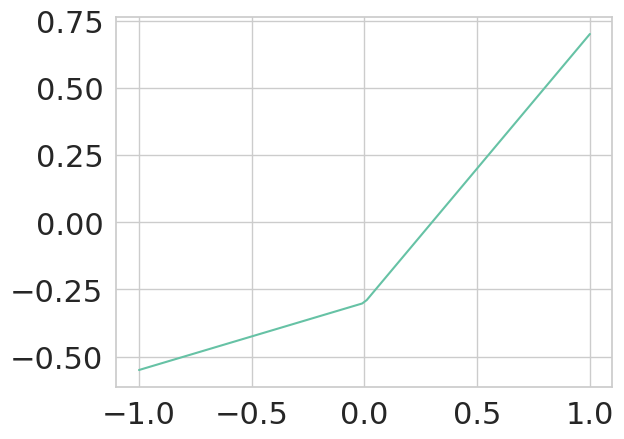

In [726]:
xs = torch.linspace(-1, 1, 100)
plt.plot(xs, GeneralReLU(leak=.25, sub=.3)(xs))

In [725]:
batch = next(iter(dl))
relu = GeneralReLU(leak=.25, sub=.3)
r_t = batch.t - batch.poi_t[batch.batch]
print(r_t.mean(), r_t.std())
r_t = (r_t - r_t.mean()) / r_t.std()
res = relu(r_t)
print(res.mean(), res.std())

tensor(-0.0695) tensor(0.3674)
tensor(-0.0649) tensor(0.6018)


In [713]:
batch = next(iter(dl))
relu = GeneralReLU(leak=.25, sub=.3)
r = (batch.pos - batch.poi_pos[batch.batch]).square().sum(1).sqrt()
print(r.mean(), r.std())
r = (r - r.mean()) / r.std()
res = relu(r)
print(res.mean(), res.std())

tensor(9.3568) tensor(4.9579)
tensor(0.0148) tensor(0.6725)


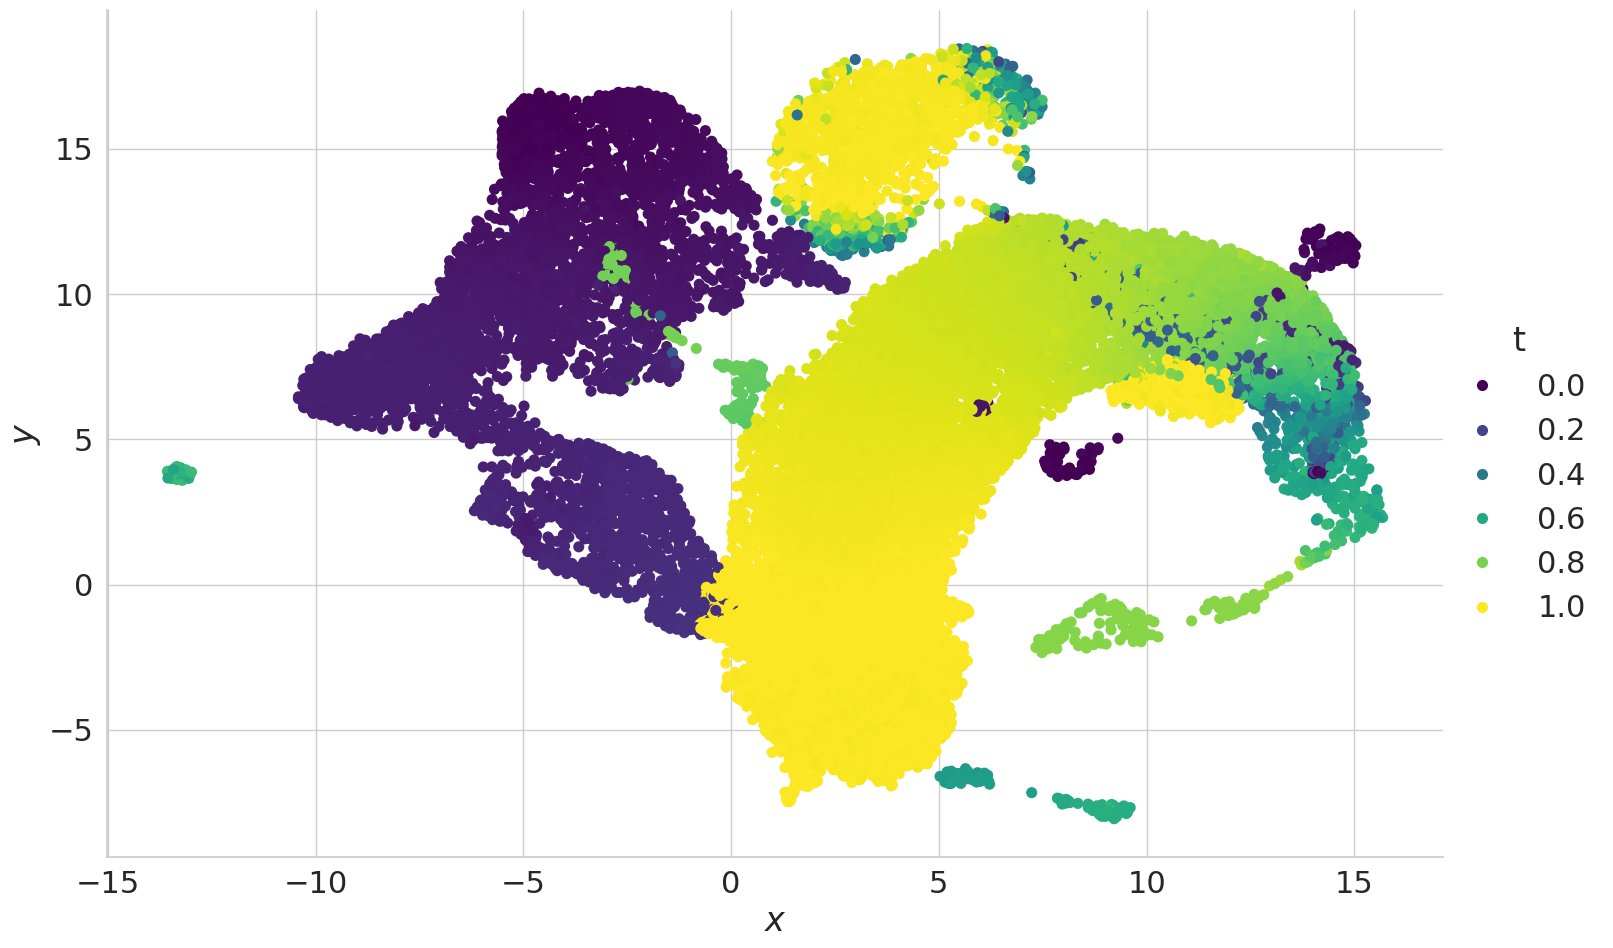

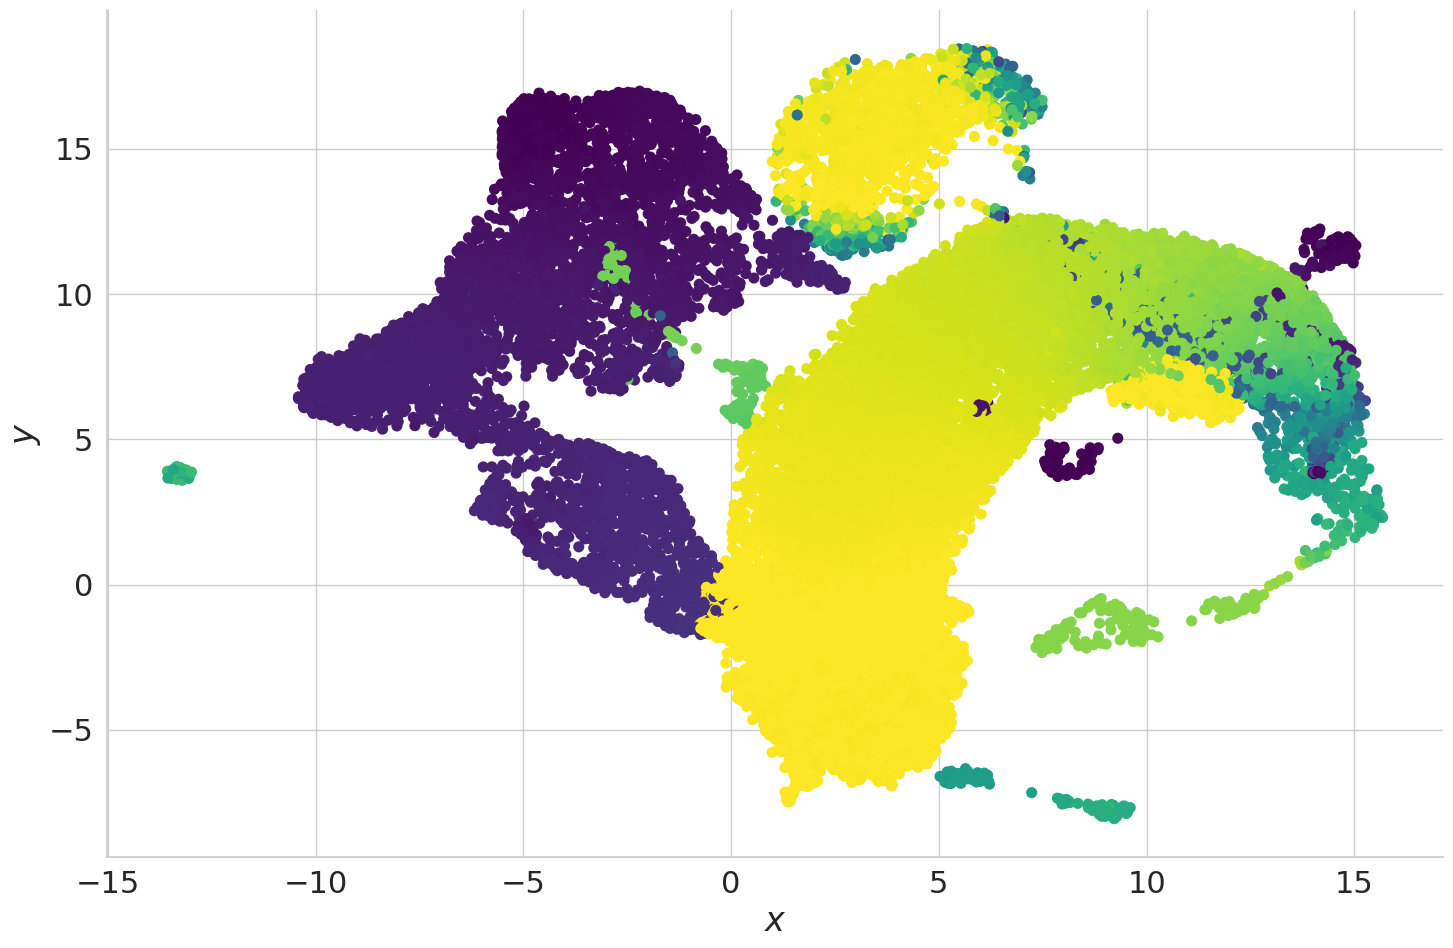

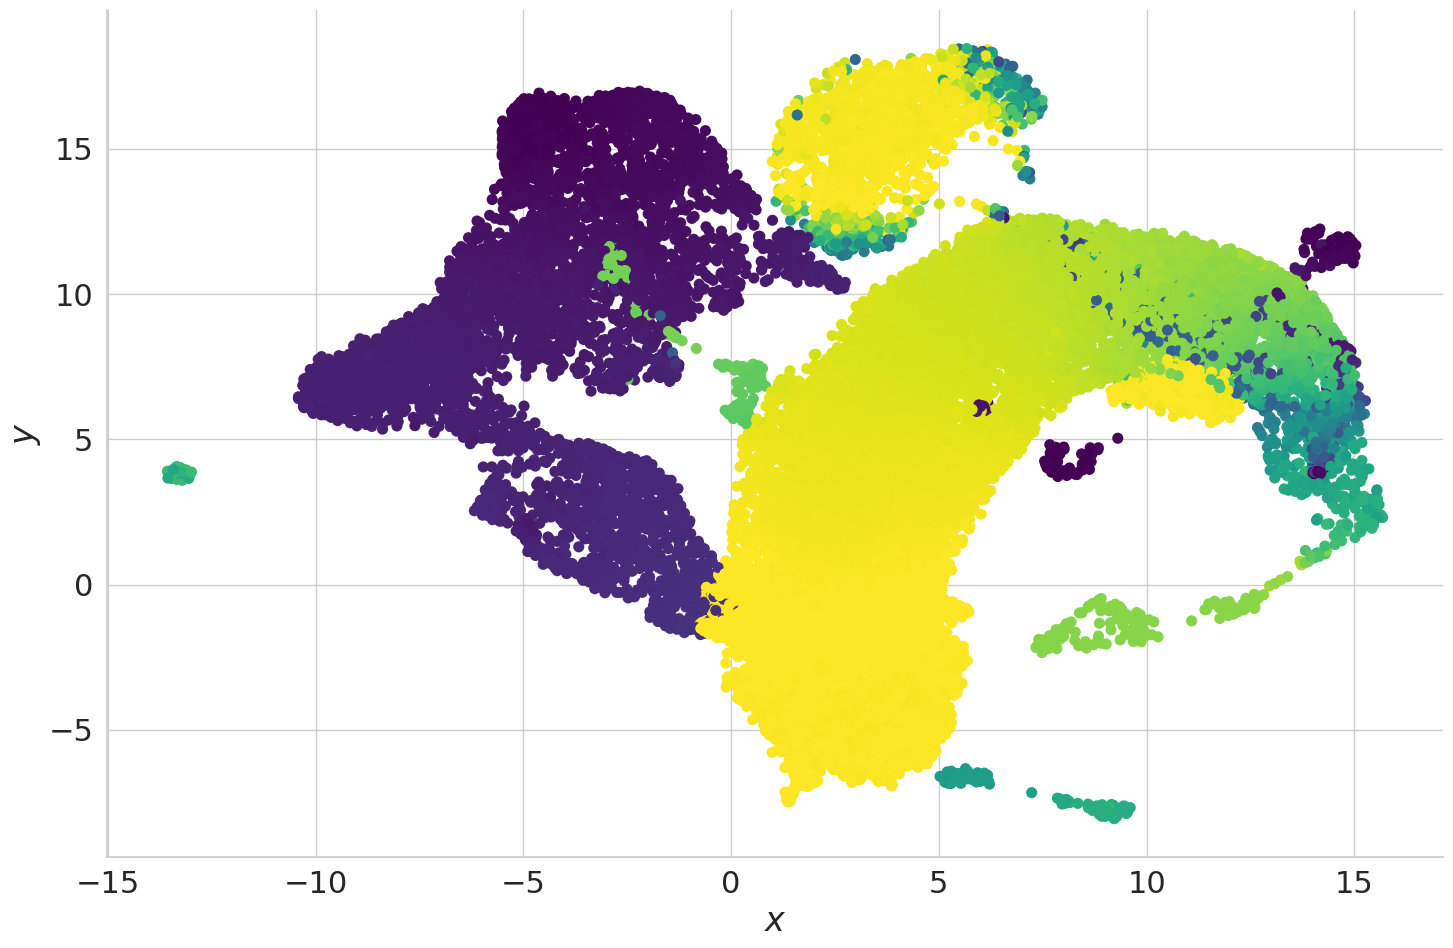

In [684]:
dfs = []
for split, dataset in splits.items():
    data = dataset.data
    df = pd.DataFrame(dict(
        measurement_id=data.poi_measurement_id,
        split=split,
        t=data.poi_t,
        **{f'x{i+1}': poi_pos_dim for i, poi_pos_dim in enumerate(data.poi_pos.T)},
        **{f'v{i+1}': poi_vel_dim for i, poi_vel_dim in enumerate(data.poi_vel.T)},
    ))
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        # row='split',
        hue='t',
        palette='viridis',
        x='x1', y='x2',
        height=10,
        aspect=1.5,
        s=64,
        edgecolor='none',
    )
    .set(
        xlabel='$x$',
        ylabel='$y$',
    )
)
plots.save_all_subfigures(plot, 'Dataset')
# for (row, col, hue), data in plot.facet_data():
#     ax = plot.axes[row][col]
#     data = data.sample(100)
#     ax.quiver(
#         data['x1'], data['x2'], data['v1'], data['v2'],
#         # headwidth=1, headlength=15, headaxislength=2,
#         color=None,
#     )

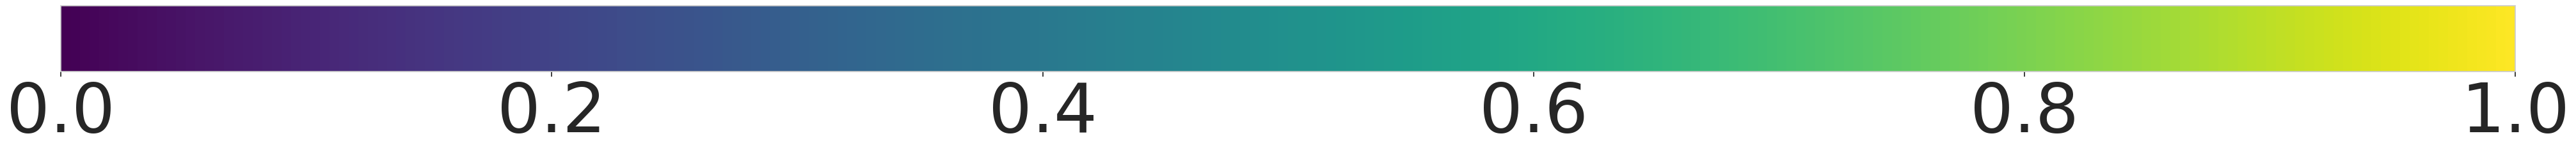

In [58]:
scale = 1.5
fig, (ax, ax_cbar) = plt.subplots(2, 1, height_ratios=[45, 1], figsize=(33*scale, 45*scale))
out = ax.imshow(np.linspace(0, 1, 10)[None], cmap='viridis')
fig.colorbar(out, cax=ax_cbar, orientation='horizontal')
ax.remove()
fig.savefig('Dataset.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

In [698]:
df.sort_values('t')

,split,t,$x_1$,$x_2$,$v_1$,$v_2$,is_poi
0,train,0.000707,7.711691,3.870412,-0.689081,0.724684,False
1,train,0.003804,7.827108,4.592371,-0.925979,0.377575,False
2,train,0.005893,14.450773,11.855510,-0.853091,0.521763,False
3,train,0.008502,8.005093,4.736732,-0.883160,0.469072,False
4,train,0.014068,14.540881,11.911176,-0.774171,0.632977,False
...,...,...,...,...,...,...,...
109,train,0.989624,4.441525,15.115441,-0.400067,-0.916486,False
110,train,0.989835,2.359589,13.679385,-0.909713,-0.415238,False
111,train,0.990056,3.593566,14.795214,-0.411487,-0.911416,False
112,train,0.990295,4.185670,16.038933,-0.550961,-0.834531,False


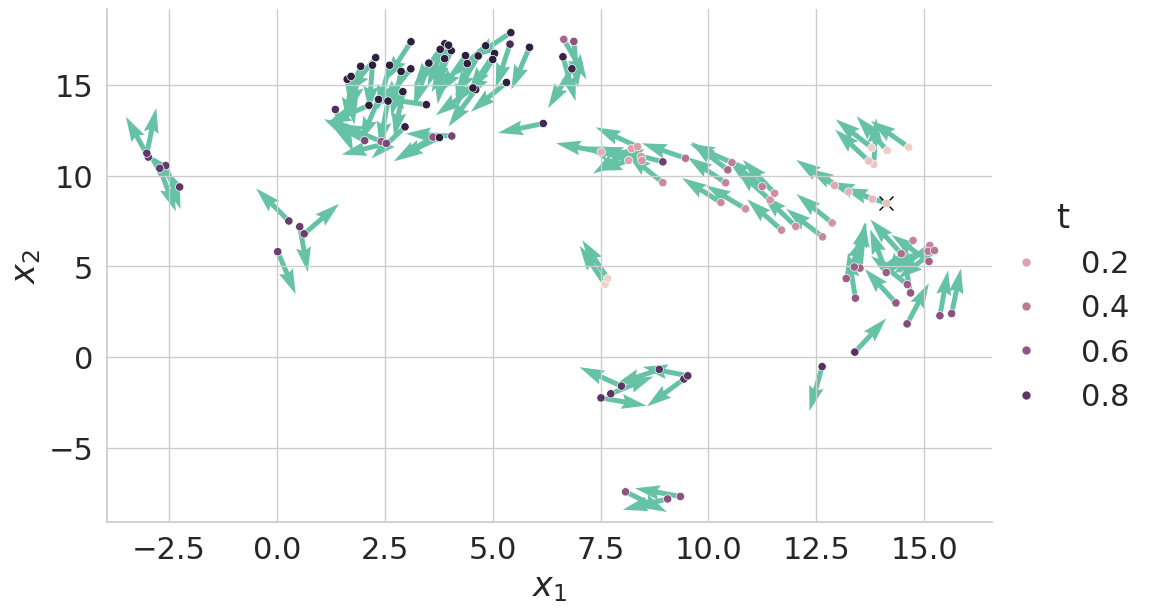

In [730]:
split = 'train'
data_idx = 1901
dataset = splits[split]
data = dataset[data_idx]
# print(data.poi_measurement_id)
# print(data)
# print(data.vel.T)
df = pd.DataFrame(dict(
    split=split,
    t=torch.cat([data.t, data.poi_t]),
    **{f'$x_{i+1}$': x for i, x in enumerate(torch.cat([data.pos, data.poi_pos]).T)},
    **{f'$v_{i+1}$': v for i, v in enumerate(torch.cat([data.vel, data.poi_vel]).T)},
    is_poi=False,
))
df.loc[df.index[-1], 'is_poi'] = True
df = df.sort_values('t', ignore_index=True)
# print(df)
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        row='split',
        hue='t',
        x='$x_1$', y='$x_2$',
        height=7,
        aspect=1.5,
        # legend=False,
    )
    .set_titles('')
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    ax.quiver(
        data['$x_1$'], data['$x_2$'], data['$v_1$'], data['$v_2$'],
        # headwidth=1, headlength=15, headaxislength=2,
        color=None,
        zorder=0,
    )
    data_poi = data.query('is_poi')
    ax.plot(data_poi['$x_1$'], data_poi['$x_2$'], 'kx', markersize=10, zorder=0)
